In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", "/home/dbekaert/Software/RS-applications"])

0

: 

# OPERA RTC-S1 Time-Series — Belgian Coast Wind Farms & Oosterweel

This notebook demonstrates searching, loading, and visualizing **OPERA Radiometric
Terrain-Corrected (RTC)** SAR backscatter from Sentinel-1 via the **NASA ASF DAAC**
using `load_dataset()` — a single call that handles catalog lookup,
STAC search, and COG loading.

The OPERA RTC-S1 record at ASF covers the **full Sentinel-1 archive** back to
October 2014 (S1A launch), providing over a decade of SAR backscatter data.

Two areas of interest are explored:

1. **North Sea wind farms** off the Belgian coast
2. **Oosterweel construction works** in Antwerp, Belgium

Imagery is composited using the ASF/HyP3 false-colour convention:
- **R** = sqrt(VV), amplitude range [0.14, 0.52]
- **G** = sqrt(VH), amplitude range [0.05, 0.259]
- **B** = sqrt(VV) (same as R)

Each frame is annotated with **sensor** (Sentinel-1A / 1B),
**orbit direction** (ASC / DESC), and **acquisition time** in UTC.
The time-series is exported as an **animated GIF** with a geodetic **scale bar**.

In [2]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from rs_tools.config import BoundingBox, SearchConfig
from rs_tools.datasets.catalog import get
from rs_tools.datasets.loader import load_dataset, LoadedItem
from rs_tools.visualization.rtc_composite import rtc_composite, plot_rtc_composite
from rs_tools.visualization.scalebar import add_scalebar
from rs_tools.visualization.animation import save_timeseries_gif_lazy
from rs_tools.visualization.overlays import fetch_roads, overlay_roads, annotate_location

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.widgets import Slider
import numpy as np
from datetime import datetime as dt

## 1. Define areas of interest

- **Wind farms**: Offshore wind farm zone in the North Sea, northwest of Zeebrugge
- **Oosterweel**: The Oosterweel Link construction site in Antwerp (tunnel under the Scheldt)

In [3]:
# North Sea wind farms off Belgian coast — expanded to capture full wind farm zone
bbox_windfarms = BoundingBox(west=2.37, south=51.33, east=3.43, north=51.89)

# Oosterweel + wider Antwerp area — zoomed out to show city and all construction sites
bbox_oosterweel = BoundingBox(west=4.30, south=51.17, east=4.48, north=51.27)

print(f"Wind farms AOI : {bbox_windfarms}")
print(f"Oosterweel AOI : {bbox_oosterweel}")

Wind farms AOI : BoundingBox(west=2.37, south=51.33, east=3.43, north=51.89)
Oosterweel AOI : BoundingBox(west=4.3, south=51.17, east=4.48, north=51.27)


## 2. Catalog entry

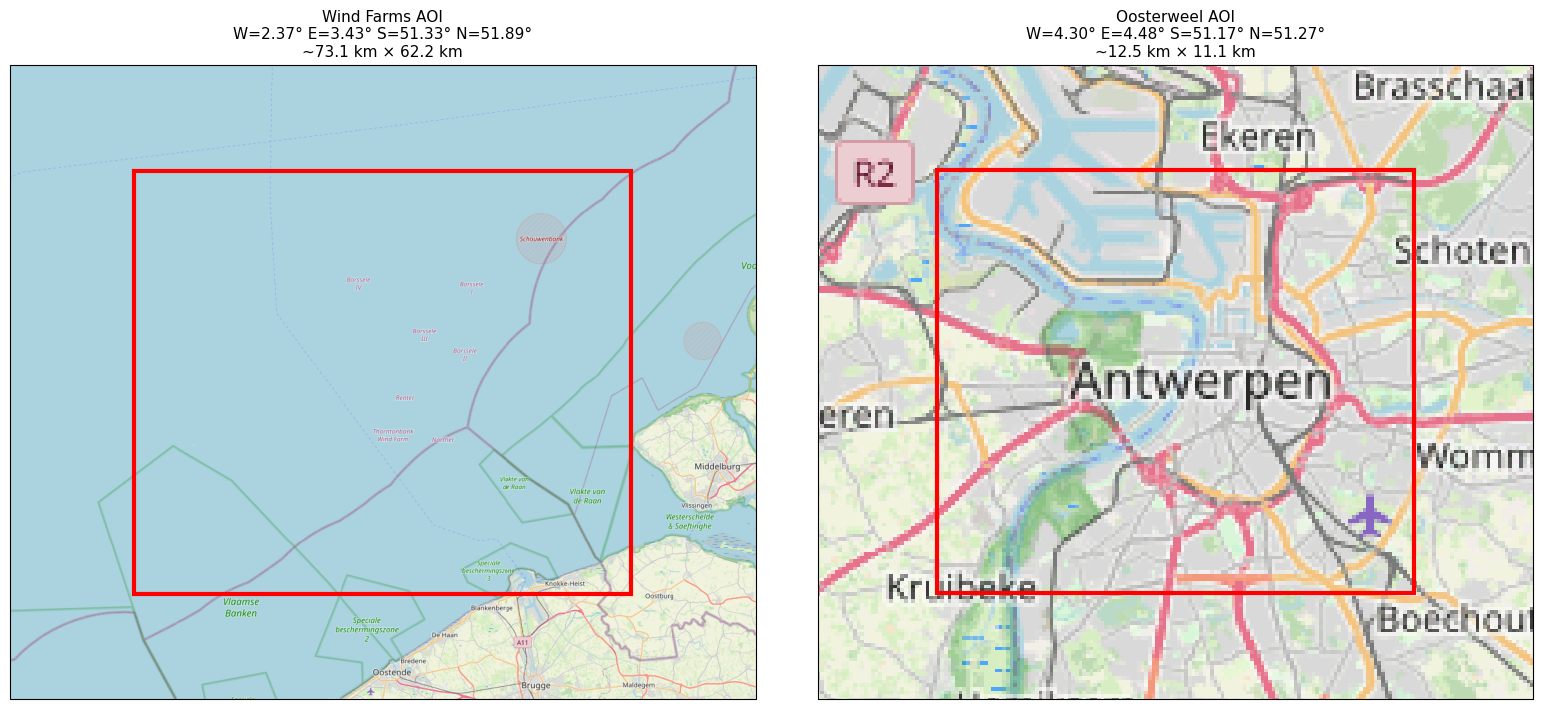

In [7]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.img_tiles import OSM
import matplotlib.patches as mpatches
import math

osm_tiles = OSM()

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                         subplot_kw={"projection": osm_tiles.crs})

for ax, bbox, title, color in [
    (axes[0], bbox_windfarms, "Wind Farms AOI", "red"),
    (axes[1], bbox_oosterweel, "Oosterweel AOI", "red"),
]:
    # Set extent with margin
    margin_lon = (bbox.east - bbox.west) * 0.25
    margin_lat = (bbox.north - bbox.south) * 0.25
    ax.set_extent([bbox.west - margin_lon, bbox.east + margin_lon,
                   bbox.south - margin_lat, bbox.north + margin_lat],
                  crs=ccrs.PlateCarree())

    # Add OSM basemap tiles (zoom level 10 for regional context)
    ax.add_image(osm_tiles, 10)

    # Draw the bounding box
    rect = mpatches.Rectangle(
        (bbox.west, bbox.south),
        bbox.east - bbox.west,
        bbox.north - bbox.south,
        linewidth=3, edgecolor=color, facecolor="none",
        transform=ccrs.PlateCarree(), zorder=10,
    )
    ax.add_patch(rect)

    # Size label
    lat_mid = (bbox.south + bbox.north) / 2
    width_km = (bbox.east - bbox.west) * math.cos(math.radians(lat_mid)) * 111
    height_km = (bbox.north - bbox.south) * 111
    ax.set_title(
        f"{title}\n"
        f"W={bbox.west:.2f}\u00b0 E={bbox.east:.2f}\u00b0 "
        f"S={bbox.south:.2f}\u00b0 N={bbox.north:.2f}\u00b0\n"
        f"~{width_km:.1f} km \u00d7 {height_km:.1f} km",
        fontsize=11,
    )

plt.tight_layout()
plt.show()

In [4]:
rtc_info = get("OPERA_RTC_S1")
print(f"Name            : {rtc_info.name}")
print(f"Spatial res.    : {rtc_info.spatial_resolution}")
print(f"Archives        : {list(rtc_info.archive_collections.keys())}")
print(f"Terrascope IDs  : {rtc_info.archive_collections['terrascope']}")
print(f"NASA/ASF IDs    : {rtc_info.archive_collections['nasa']}")

Name            : OPERA RTC-S1
Spatial res.    : 30 m
Archives        : ['terrascope', 'nasa']
Terrascope IDs  : ['opera-s1-rtc-v1']
NASA/ASF IDs    : ['OPERA_L2_RTC-S1_V1_1']


## 3. Data access authentication

OPERA RTC data is loaded from the **Terrascope STAC** catalogue via HTTPS
using `~/.netrc` credentials for `services.terrascope.be`. GDAL streams
COGs using HTTP Basic Auth.

In [ ]:
# Terrascope auth is handled via ~/.netrc (machine services.terrascope.be)
# GDAL_HTTP_AUTH=BASIC is configured automatically by load_dataset()
print("Terrascope credentials available via ~/.netrc")

NASA Earthdata credentials available via ~/.netrc


In [ ]:
# Load OPERA RTC — Wind Farms — last 2 years, one per 6 months
# monthly=True + interval_months=6 → ~4 passes for a quick overview
data_wf = load_dataset(
    "OPERA_RTC_S1",
    bbox=bbox_windfarms,
    start_date="2024-01-01",
    end_date="2026-03-22",
    archive="terrascope",
    limit=500,
    monthly=True,
    interval_months=6,
)
print(f"\nLoaded {len(data_wf)} samples for wind farms (every 6 months)")

  2014-10: no data
  2015-04: no data
  2015-10: no data
  2016-04: 426 items → 49 bursts (1 pass)
  2016-10: 500 items → 28 bursts (1 pass)
  2017-04: 500 items → 24 bursts (1 pass)
  2017-10: 500 items → 29 bursts (1 pass)
  2018-04: 500 items → 32 bursts (1 pass)
  2018-10: 500 items → 32 bursts (1 pass)
  2019-04: 500 items → 24 bursts (1 pass)
  2019-10: 500 items → 32 bursts (1 pass)
  2020-04: 500 items → 24 bursts (1 pass)
  2020-10: 500 items → 26 bursts (1 pass)
  2021-04: 500 items → 24 bursts (1 pass)
  2021-10: 500 items → 40 bursts (1 pass)
  2022-04: 500 items → 48 bursts (1 pass)
  2022-10: 500 items → 48 bursts (1 pass)
  2023-04: 500 items → 48 bursts (1 pass)
  2023-10: 500 items → 37 bursts (1 pass)
  2024-04: 500 items → 48 bursts (1 pass)
  2024-10: 500 items → 48 bursts (1 pass)
  2025-04: 500 items → 24 bursts (1 pass)
  2025-10: 500 items → 32 bursts (1 pass)
Found 697 items for OPERA_RTC_S1 in nasa
  [1/697] Sentinel-1A | DES | 2016-04-22 06:06 UTC
  [2/697] S

## 4 & 5. Load real OPERA RTC data

`load_dataset()` searches NASA's ASF archive via `asf_search` and loads VV/VH
COGs clipped to each AOI. Individual burst granules from the same satellite pass
are automatically mosaicked into continuous images using `mosaic_items()`, so
each returned `LoadedItem` represents a complete pass over the AOI.

In [ ]:
# Load OPERA RTC — Oosterweel — last 2 years, one per 6 months
# monthly=True + interval_months=6 → ~4 passes for a quick overview
data_ow = load_dataset(
    "OPERA_RTC_S1",
    bbox=bbox_oosterweel,
    start_date="2024-01-01",
    end_date="2026-03-22",
    archive="terrascope",
    limit=500,
    monthly=True,
    interval_months=6,
)
print(f"\nLoaded {len(data_ow)} samples for Oosterweel (every 6 months)")

## 6. Inspect loaded items

Each `LoadedItem` carries parsed metadata: sensor, orbit direction, UTC time.

In [ ]:
print("Wind farms items:")
for item in data_wf[:5]:
    print(f"  {item.label}  CRS={item.crs}  pixel={item.pixel_size_m} m")
    print(f"    assets: {list(item.data.keys())}  shape: {item.data['VV'].shape}")

print(f"\nOosterweel items:")
for item in data_ow[:5]:
    print(f"  {item.label}")

## 7. Acquisition timeline

Plot the temporal distribution of loaded items with sensor labels.

In [ ]:
fig, ax = plt.subplots(figsize=(14, 3))

for items, y, color, name in [
    (data_wf, 1, "steelblue", "Wind farms"),
    (data_ow, 0, "darkorange", "Oosterweel"),
]:
    dates = [item.datetime for item in items]
    ax.scatter(dates, [y] * len(dates), marker="|", s=300,
              c=color, linewidths=2, label=f"{name} ({len(dates)})")
    for item in items:
        ax.annotate(item.platform.split("-")[1],
                    (item.datetime, y), fontsize=6, ha="center",
                    va="bottom" if y == 1 else "top",
                    xytext=(0, 4 if y == 1 else -4),
                    textcoords="offset points", color=color)

ax.set_yticks([])
ax.set_title("OPERA RTC-S1 acquisition timeline")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 8. RTC false-colour composites from real COG data

Each composite is annotated with sensor, orbit direction, and UTC time.
A geodetic scale bar shows ground distance.

In [ ]:
# Wind farms — latest item
if data_wf:
    item = data_wf[-1]
    vv = item.data["VV"].values
    vh = item.data["VH"].values

    fig, ax = plt.subplots(figsize=(10, 10))
    rgb = rtc_composite(vv, vh)
    ax.imshow(rgb, origin="upper")
    ax.set_axis_off()
    ax.set_title(f"Wind farms — {item.label}", fontsize=13)
    ax.text(0.02, 0.02, item.label, transform=ax.transAxes, fontsize=10,
            color="white", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7),
            verticalalignment="bottom")
    if item.pixel_size_m:
        add_scalebar(ax, item.pixel_size_m)
    plt.tight_layout()
    plt.show()

In [ ]:
# Oosterweel — latest item with road network and construction site annotations
if data_ow:
    item = data_ow[-1]
    vv = item.data["VV"].values
    vh = item.data["VH"].values

    fig, ax = plt.subplots(figsize=(12, 10))
    rgb = rtc_composite(vv, vh)
    ax.imshow(rgb, origin="upper")
    ax.set_axis_off()
    ax.set_title(f"Oosterweel — {item.label}", fontsize=13)

    # Overlay road network from OpenStreetMap
    roads = fetch_roads(
        bbox=(bbox_oosterweel.south, bbox_oosterweel.west,
              bbox_oosterweel.north, bbox_oosterweel.east),
        highway_types="motorway|trunk|primary|secondary",
    )
    overlay_roads(ax, roads, item.data["VV"],
                  color="#888888", linewidth=0.4, alpha=0.5)

    # Annotate key locations
    annotations = [
        (4.3925, 51.2340, "Oosterweel\ntunnel north"),
        (4.3885, 51.2210, "Scheldt\ncrossing"),
        (4.4035, 51.2140, "Linkeroever\ntunnel south"),
        (4.4220, 51.2230, "Port of\nAntwerp"),
        (4.3560, 51.2170, "Antwerp\ncity centre"),
        (4.4150, 51.2470, "R1 ring\nmotorway"),
    ]
    for lon, lat, label in annotations:
        annotate_location(ax, lon, lat, label, item.data["VV"],
                          color="cyan", fontsize=7, markersize=3)

    ax.text(0.02, 0.02, item.label, transform=ax.transAxes, fontsize=10,
            color="white", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7),
            verticalalignment="bottom")
    if item.pixel_size_m:
        add_scalebar(ax, item.pixel_size_m)
    plt.tight_layout()
    plt.show()

## 9. Animated GIF export

Build RTC composites for every loaded date and save as animated GIFs.
Each frame carries the sensor label, orbit direction, and acquisition time in UTC.

In [ ]:
import os
gif_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "gifs")
os.makedirs(gif_dir, exist_ok=True)

def _rtc_composite_fn(item):
    """Compositing callback for lazy GIF generation."""
    vv = item.data["VV"].values
    vh = item.data["VH"].values
    rgb = rtc_composite(vv, vh)
    return rgb, item.label

# Wind farms GIF — only one frame in memory at a time
if data_wf:
    save_timeseries_gif_lazy(
        data_wf, os.path.join(gif_dir, "windfarms_rtc.gif"),
        composite_fn=_rtc_composite_fn,
        title="North Sea Wind Farms — OPERA RTC-S1",
        pixel_size_m=data_wf[0].pixel_size_m, fps=2,
    )

# Oosterweel GIF
if data_ow:
    save_timeseries_gif_lazy(
        data_ow, os.path.join(gif_dir, "oosterweel_rtc.gif"),
        composite_fn=_rtc_composite_fn,
        title="Oosterweel — OPERA RTC-S1",
        pixel_size_m=data_ow[0].pixel_size_m, fps=2,
    )

## 10. Interactive time-series slider

Step through loaded RTC composites with an interactive slider.
The annotation updates with sensor, orbit, and UTC time.

In [ ]:
if data_wf:
    fig, ax = plt.subplots(figsize=(9, 9))
    plt.subplots_adjust(bottom=0.15)

    # Compute first composite for initial display
    _first_rgb = rtc_composite(data_wf[0].data["VV"].values,
                                data_wf[0].data["VH"].values)
    im = ax.imshow(_first_rgb, origin="upper")
    ax.set_axis_off()
    ax.set_title(f"Wind farms — {data_wf[0].label}", fontsize=12)
    if data_wf[0].pixel_size_m:
        add_scalebar(ax, data_wf[0].pixel_size_m)

    txt = ax.text(0.02, 0.02, data_wf[0].label, transform=ax.transAxes,
                  fontsize=10, color="white", fontweight="bold",
                  bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7),
                  verticalalignment="bottom")

    ax_slider = fig.add_axes([0.15, 0.04, 0.70, 0.03])
    slider = Slider(ax_slider, "Date", 0, len(data_wf) - 1, valinit=0, valstep=1)

    def _update(val):
        idx = int(slider.val)
        item = data_wf[idx]
        # Compute composite on-demand — avoids holding all frames in memory
        rgb = rtc_composite(item.data["VV"].values, item.data["VH"].values)
        im.set_data(rgb)
        ax.set_title(f"Wind farms — {item.label}", fontsize=12)
        txt.set_text(item.label)
        fig.canvas.draw_idle()

    slider.on_changed(_update)
    plt.show()

## 11. Backscatter time-series (dB)

Mean VV/VH backscatter over each AOI from real pixel data.

In [ ]:
def mean_backscatter_db(items):
    """Compute mean VV/VH in dB for each loaded item."""
    dates, vv_db, vh_db, sensors = [], [], [], []
    for item in items:
        vv = item.data["VV"].values
        vh = item.data["VH"].values
        vv_mean = np.nanmean(vv[vv > 0])
        vh_mean = np.nanmean(vh[vh > 0])
        if vv_mean > 0 and vh_mean > 0:
            dates.append(item.datetime)
            vv_db.append(10 * np.log10(vv_mean))
            vh_db.append(10 * np.log10(vh_mean))
            sensors.append(item.platform.split("-")[1])
    return dates, vv_db, vh_db, sensors

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, items, title in [
    (axes[0], data_wf, "North Sea wind farms"),
    (axes[1], data_ow, "Oosterweel"),
]:
    dates, vv, vh, sensors = mean_backscatter_db(items)
    ax.plot(dates, vv, "o-", color="steelblue", ms=4, lw=1, label="VV (dB)")
    ax.plot(dates, vh, "s-", color="darkorange", ms=4, lw=1, label="VH (dB)")
    for d, v, s in zip(dates, vv, sensors):
        ax.annotate(s, (d, v), fontsize=6, ha="center", va="bottom",
                    xytext=(0, 3), textcoords="offset points", color="steelblue")
    ax.set_ylabel("Backscatter (dB)")
    ax.set_title(f"{title} — VV / VH backscatter")
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel("Acquisition date")
for a in axes:
    a.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    a.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Next steps

- **Expand temporal range** to observe seasonal changes in backscatter
- **Change detection**: compare construction progress at Oosterweel across dates
- **Switch archive**: use `load_dataset(..., archive="nasa")` to load from ASF instead
- **Stack composites**: mosaic multiple bursts per date for full AOI coverage
- **Classification**: use VV/VH ratio to distinguish water, vegetation, urban